In [1]:
import os
import numpy as np
import pandas as pd
import scipy

from IPython.display import display
from tqdm.auto import tqdm

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt

from src.styles import *
from src.visualization import *
from src.preprocessing import *
from src.training import *

In [2]:
##########
# Data Import
##########

# Variable Definition
local_dir = "data"
path_reviews = f"{local_dir}/combined_reviews.csv"
stopword_path = "data/stopwords_custom.json"

# Import data to pandas dataframe
df_reviews = pd.read_csv(path_reviews)

df_reviews["language"] = df_reviews["origin"].map({
    "FragdenStaat": "de",
    "YELP": "en",
})

# Remove duplicate Requests
df_reviews = remove_duplicate_texts(df_reviews, text_col="review")


##########
# Stopword Definition
##########

# Import Sentiment Stopwords based on threshold
sia_en = SentimentIntensityAnalyzer()
de_thres = 2
en_thres = 1.5

vader_words_en = load_vader_words(sia_en, en_thres)
gervader_words_de = load_gervader_words("GerVADER/GERVaderLexicon.txt", de_thres)

# Build Basis-Dictionary
dict_stopw_default = {
    "iter_0": {
        "de_nltk_common": stopwords.words("german"),
        "de_vader_topic_only":gervader_words_de,
        "en_nltk_common": stopwords.words("english"),
        "en_vader_topic_only":vader_words_en,
        
    },
    "iter_1": {
        "de_custom_common": [],
        "de_custom_topic_only": [],
        "en_custom_common": [],
        "en_custom_topic_only": []
    }
}


=== Duplikat-Entfernung ===
Vorher: 2000 Zeilen
Nachher: 1749 Zeilen
Entfernt: 251 Duplikate


In [3]:
##########
# Data PreProcessing
##########

top_n = 30       # Anzahl anzuzeigender TopWörter
n_process = 1    # Anzahl paralleler Prozesse, Performace-Tunin

while True:
    # Stopwörter JSON laden oder neu erstellen
    if os.path.exists(stopword_path) and os.path.getsize(stopword_path) > 0:
        print("Stopwort-Datei gefunden -> wird eingelesen")
        dict_stopw = load_stopw_from_json(stopword_path)

        if "iter_0" not in dict_stopw:
            dict_stopw["iter_0"] = dict_stopw_default["iter_0"]
            write_stopw_to_json(dict_stopw, stopword_path)

    else:
        print("Stopwort-Datei fehlt oder ist leer -> wird erstellt")
        dict_stopw = dict_stopw_default
        write_stopw_to_json(dict_stopw, stopword_path)

    # Stopwörter zusammenführen
    stopwords_all = build_stopword_lists_from_iterations(dict_stopw)

    stopw_topic_de, stopw_sent_de = stopwords_all["topic_de"], stopwords_all["sentiment_de"]
    stopw_topic_en, stopw_sent_en = stopwords_all["topic_en"], stopwords_all["sentiment_en"]

    # Cleaning Topic/ Sentiment Data
    print("\nCleaning Data - Topic Modeling")
    data_topic = clean_and_tokenize(df_reviews,stopw_de=stopw_topic_de,stopw_en=stopw_topic_en,n_process=n_process)

    print("\nCleaning Data - Sentiment Analysis")
    data_sentiment = clean_and_tokenize(df_reviews,stopw_de=stopw_sent_de,stopw_en=stopw_sent_en,n_process=n_process)

    # Vergleichstabelle anzeigen
    compare_top_tokens_table = compare_top_tokens(
        data_topic,
        data_sentiment,
        top_n
    )
    print()
    display(
        style_compare_top_tokens(
            compare_top_tokens_table,
            caption=f"Vergleich Top {top_n} Token (de/en)"
        )
    )

    current_iter = get_current_iteration_key(dict_stopw)
    
    print(
        f"\nBitte Top Token prüfen und ggf. unter '{current_iter}' in {stopword_path} ergänzen."
    )
    print("1 = JSON ergänzt, nächste Iteration starten")
    print("2 = fertig, weiter mit Topic Modeling")
    
    choice = input("Auswahl: ").strip()
    
    if choice == "1":
        # JSON neu laden (mit deinen Ergänzungen)
        dict_stopw = load_stopw_from_json(stopword_path)
    
        # nächste Iteration vorbereiten
        add_iter_to_json(dict_stopw, stopword_path)
    
    elif choice == "2":
        print("\nFinale Stopwörter übernommen. Weiter mit Topic Modeling.")
        break
    
    else:
        print("\nUngültige Eingabe. Bitte 1 oder 2 wählen.")

Stopwort-Datei gefunden -> wird eingelesen

Cleaning Data - Topic Modeling


Englisch verarbeiten: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 87.86it/s]



Cleaning Data - Sentiment Analysis


Englisch verarbeiten: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:10<00:00, 94.78it/s]



Bitte Top Token prüfen und ggf. unter 'iter_9' in data/stopwords_custom.json ergänzen.
1 = JSON ergänzt, nächste Iteration starten
2 = fertig, weiter mit Topic Modeling


Auswahl:  2



Finale Stopwörter übernommen. Weiter mit Topic Modeling.


In [4]:
############
# Create Vectors with BoW & TF-IDF
############

# Separate Pipelines: Topic Modeling vs. Sentiment
print("Creating Vectors - Topic Modeling")
vectors_topic = {}
vectors_topic["bow_by_lang"] = vectorize(CountVectorizer, data_topic)
vectors_topic["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_topic)

print("\nCreating Vectors - Sentiment Analysis")
vectors_sentiment = {}
vectors_sentiment["bow_by_lang"] = vectorize(CountVectorizer, data_sentiment)
vectors_sentiment["tfidf_by_lang"] = vectorize(TfidfVectorizer, data_sentiment)

Creating Vectors - Topic Modeling
de: 749 Dokumente, 3080 Features
en: 999 Dokumente, 2152 Features
de: 749 Dokumente, 3080 Features
en: 999 Dokumente, 2152 Features

Creating Vectors - Sentiment Analysis
de: 749 Dokumente, 3158 Features
en: 1000 Dokumente, 2598 Features
de: 749 Dokumente, 3158 Features
en: 1000 Dokumente, 2598 Features


In [8]:
############
# LDA/BoW - Model Tuning (en|de)
############

lda_tuning_results_by_lang = {}

for lang, data in vectors_topic["bow_by_lang"].items():
    lda_tuning_results_by_lang[lang] = tune_lda_models(
        data=data,
        topic_grid=[5, 10, 15, 20],
        alpha_grid=[0.01, 0.1],
        eta_grid=[0.01, 0.1],
        max_iter_grid=[10, 20],
        random_states=[1, 2, 3],
        learning_method="batch",
        lang=lang
    )

LDA Tuning (en): 100%|██████████████████| 32/32 [15:11<00:00, 28.50s/it, k=20, iter=20, coh=0.76, std=0.013, perp=1956]


In [31]:
############
# LDA/BoW - Tuning Validation (en|de)
############

lda_tuning_config = [
    {"col": "coherence",               "weight": 0.30, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.2f}"},
    {"col": "coherence_std",           "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"},
    
    {"col": "perplexity",              "weight": 0.20, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    #{"col": "perplexity_std",          "weight": 0.05, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"},
    
    {"col": "largest_topic_share",     "weight": 0.15, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    #{"col": "largest_topic_share_std", "weight": 0.05, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"},
    
    {"col": "avg_word_overlap",        "weight": 0.10, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    #{"col": "max_word_overlap",        "weight": 0.05, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.2f}"}
]

lda_tuning_interpreted_by_lang = {}

for lang, tuning_df_lang in lda_tuning_results_by_lang.items():

    tuning_interpreted = evaluate_and_score_tuning_generic(
        tuning_df=tuning_df_lang,
        score_metrics=lda_tuning_config
    )

    lda_tuning_interpreted_by_lang[lang] = tuning_interpreted

    print(f"\n=== LDA/BoW Tuning ({lang}) ===")

    display(
        style_tuning_eval_generic(
            tuning_interpreted.head(15),  # ← hier begrenzen
            style_metrics=lda_tuning_config,
            hide_cols=["topic_words", "topic_terms", "doc_topic_matrix", "model", "max_word_overlap", "largest_topic_share_std", "perplexity_std"]
        )
    )


=== LDA/BoW Tuning (de) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
27,20,0.010000,0.100000,20,2.05,0.02,1401.0992,0.0881,0.0119,1,0.8038
26,20,0.010000,0.100000,10,2.04,0.01,1412.2601,0.0877,0.0121,3,0.7958
30,20,0.100000,0.100000,10,2.03,0.04,1500.2945,0.0872,0.0108,3,0.7653
31,20,0.100000,0.100000,20,2.02,0.05,1487.2424,0.0908,0.0110,1,0.7554
29,20,0.100000,0.010000,20,2.07,0.02,1939.7453,0.0854,0.0099,1,0.7116
28,20,0.100000,0.010000,10,2.03,0.02,1989.6576,0.0850,0.0110,3,0.6615
25,20,0.010000,0.010000,20,2.00,0.06,1903.1144,0.0832,0.0120,3,0.6321
24,20,0.010000,0.010000,10,2.00,0.06,1954.0436,0.0846,0.0118,3,0.6221
18,15,0.010000,0.100000,10,1.91,0.20,1460.0571,0.1166,0.0111,1,0.5842
19,15,0.010000,0.100000,20,1.92,0.21,1441.8959,0.1153,0.0118,1,0.5835



=== LDA/BoW Tuning (en) ===


,n_topics,alpha,eta,max_iter,coherence,coherence_std,perplexity,largest_topic_share,avg_word_overlap,best_seed,overall_score
31,20,0.100000,0.100000,20,0.76,0.01,1955.6742,0.0881,0.0764,1,0.7866
30,20,0.100000,0.100000,10,0.70,0.01,2007.2281,0.0851,0.0953,1,0.7171
27,20,0.010000,0.100000,20,0.70,0.04,1794.4206,0.0941,0.0906,2,0.6798
26,20,0.010000,0.100000,10,0.66,0.02,1823.6504,0.0884,0.0954,2,0.6604
29,20,0.100000,0.010000,20,0.76,0.02,3280.6282,0.0747,0.0785,1,0.6470
18,15,0.010000,0.100000,10,0.66,0.03,1751.2856,0.1018,0.1094,2,0.6331
19,15,0.010000,0.100000,20,0.67,0.05,1720.1484,0.1061,0.1067,2,0.6229
23,15,0.100000,0.100000,20,0.70,0.07,1814.6157,0.1048,0.0996,2,0.6188
22,15,0.100000,0.100000,10,0.67,0.06,1858.0745,0.1034,0.1073,2,0.5967
15,10,0.100000,0.100000,20,0.66,0.04,1677.3955,0.1495,0.1112,1,0.5947


In [36]:
############
# LSA/TF-IDF - Model Tuning (en|de)
############

lsa_tuning_results_by_lang = {}

for lang, data in vectors_topic["tfidf_by_lang"].items():
    lsa_tuning_results_by_lang[lang] = tune_lsa_models(
        data=data,

        # Anzahl semantischer Komponenten
        # mehr = feinere Trennung, aber schwerer interpretierbar
        topic_grid=[10, 20, 30, 40],

        # Iterationen der randomized SVD
        # mehr = stabilere Approximation, aber langsamer
        n_iter_grid=[10, 20, 30],

        # fixer Seed für reproduzierbare Ergebnisse
        random_state=42,

        # nur für Progress/Logging
        lang=lang
    )

LSA Tuning (en): 100%|██████████████████████████████| 12/12 [00:39<00:00,  3.28s/it, k=40, iter=30, coh=0.48, var=0.18]


In [39]:
############
# LSA/TF-IDF - Tuning Validation (en|de)
############

lsa_tuning_config = [
    {"col": "avg_word_overlap",     "weight": 0.16, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
    {"col": "coherence",            "weight": 0.42, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "explained_variance",   "weight": 0.17, "higher_is_better": True,  "good_quantile": 0.75, "bad_quantile": 0.25, "format": "{:.4f}"},
    {"col": "largest_topic_share",  "weight": 0.25, "higher_is_better": False, "good_quantile": 0.25, "bad_quantile": 0.75, "format": "{:.4f}"},
]

lsa_tuning_interpreted_by_lang = {}

for lang, tuning_df_lang in lsa_tuning_results_by_lang.items():

    tuning_interpreted = evaluate_and_score_tuning_generic(
        tuning_df=tuning_df_lang,
        score_metrics=lsa_tuning_config
    )

    lsa_tuning_interpreted_by_lang[lang] = tuning_interpreted

    print(f"\n=== LSA/TF-IDF Tuning ({lang}) ===")

    display(
        style_tuning_eval_generic(
            tuning_interpreted.head(10),
            style_metrics=lsa_tuning_config,
            hide_cols=["topic_words", "topic_terms", "doc_topic_matrix", "model"]
        )
    )


=== LSA/TF-IDF Tuning (de) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
0,10,10,2.6949,0.5167,0.1293,0.0131,0.111111,0.5848
2,10,30,2.6951,0.5234,0.1293,0.0131,0.111111,0.5800
1,10,20,2.6951,0.5234,0.1293,0.0131,0.111111,0.5800
11,40,30,2.0006,0.1816,0.2574,0.0449,0.538462,0.5120
10,40,20,1.9663,0.1856,0.2573,0.0459,0.538462,0.4870
9,40,10,1.9269,0.1829,0.2569,0.0498,0.538462,0.4530
7,30,20,2.0233,0.2256,0.2196,0.0509,0.538462,0.4197
8,30,30,2.0135,0.2296,0.2196,0.0509,0.538462,0.4117
5,20,30,2.1697,0.3084,0.1780,0.0482,0.538462,0.3922
4,20,20,2.1754,0.3084,0.1780,0.0496,0.538462,0.3899



=== LSA/TF-IDF Tuning (en) ===


,n_topics,n_iter,coherence,largest_topic_share,explained_variance,avg_word_overlap,max_word_overlap,overall_score
10,40,20,0.4919,0.3223,0.1802,0.0968,0.666667,0.9960
11,40,30,0.4847,0.3243,0.1802,0.0979,0.666667,0.9721
9,40,10,0.4762,0.3183,0.1797,0.0964,0.666667,0.9537
7,30,20,0.4421,0.3824,0.1460,0.1293,0.666667,0.7111
8,30,30,0.4401,0.3834,0.1460,0.1299,0.666667,0.7039
6,30,10,0.4247,0.3914,0.1458,0.1288,0.666667,0.6529
3,20,10,0.4128,0.4474,0.1072,0.1696,0.666667,0.4654
4,20,20,0.4076,0.4505,0.1073,0.1698,0.666667,0.4476
5,20,30,0.4069,0.4505,0.1073,0.1694,0.666667,0.4460
2,10,30,0.3526,0.5956,0.0616,0.2327,0.666667,0.0199


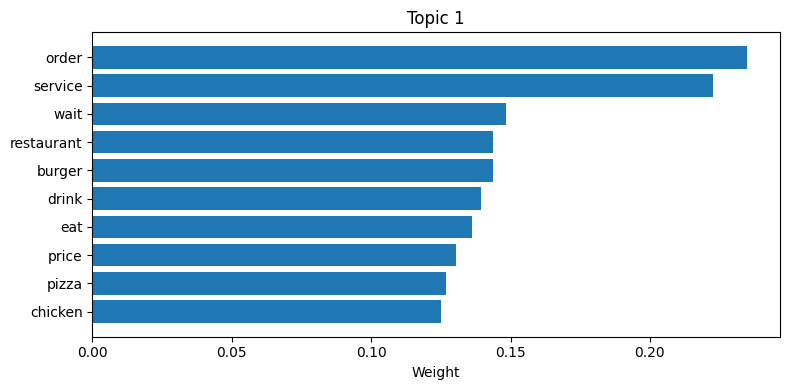

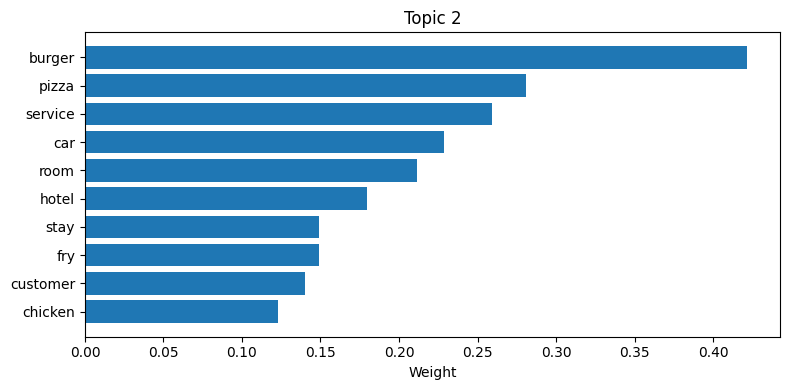

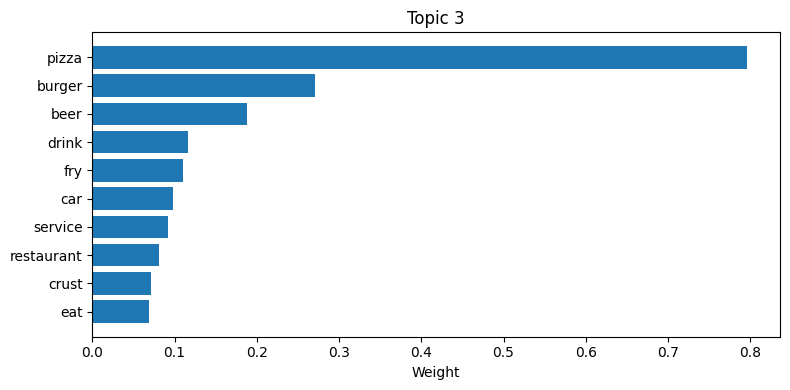

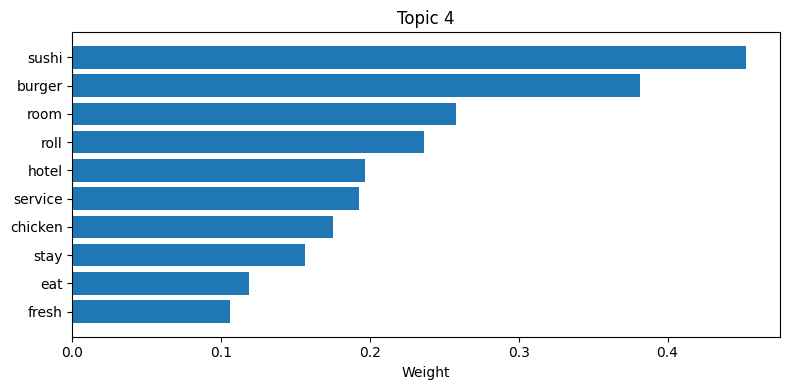

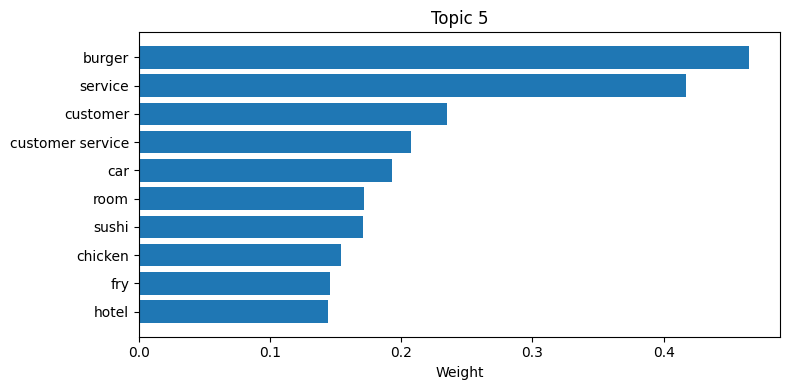

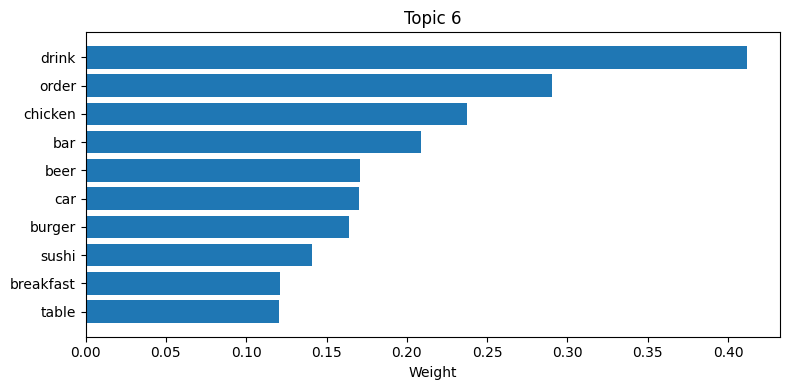

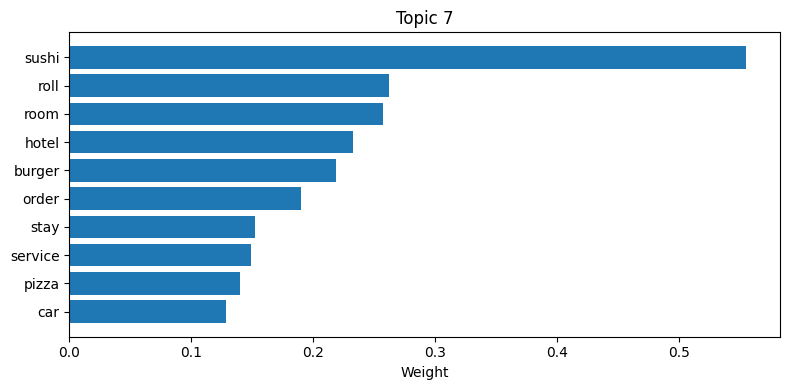

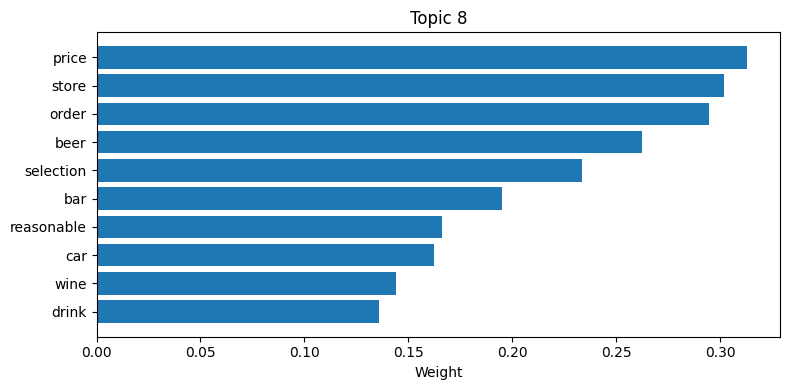

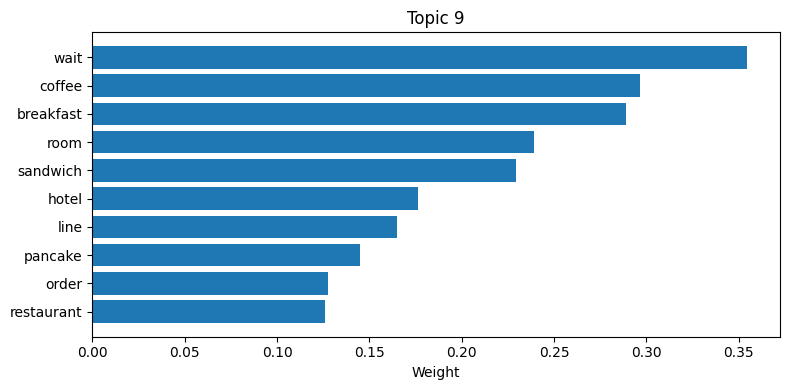

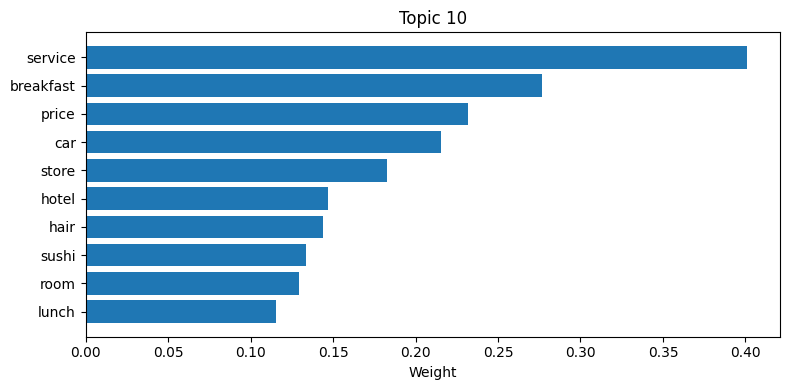

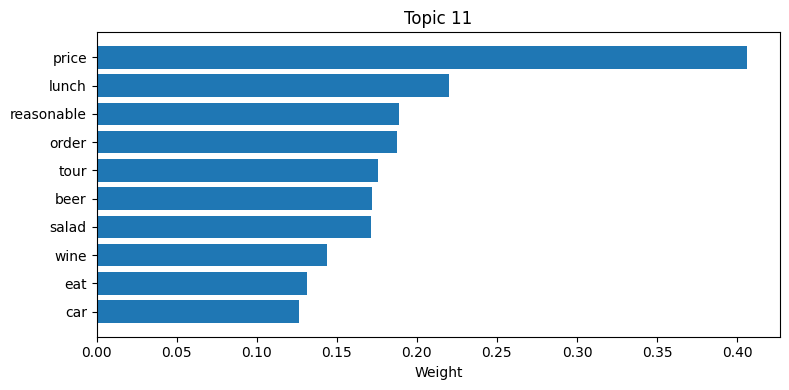

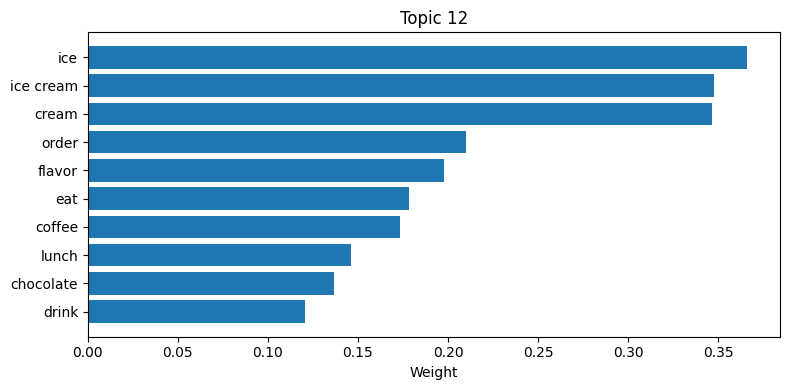

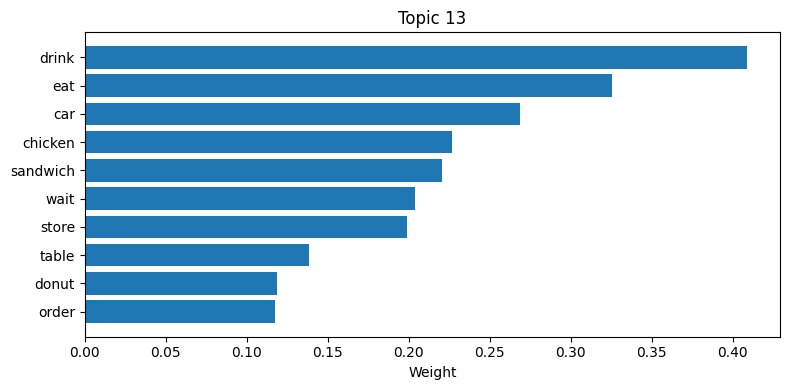

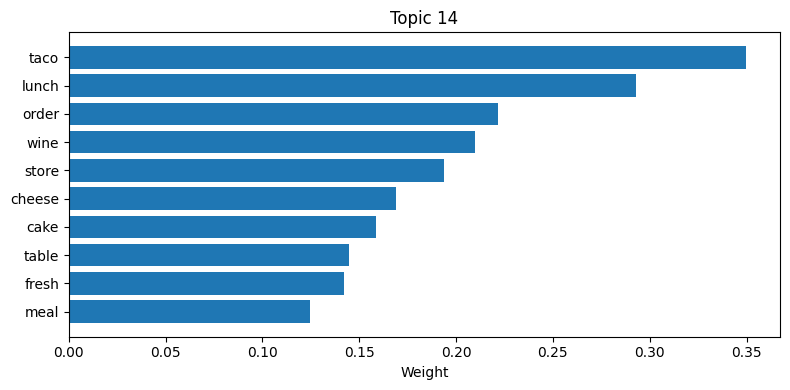

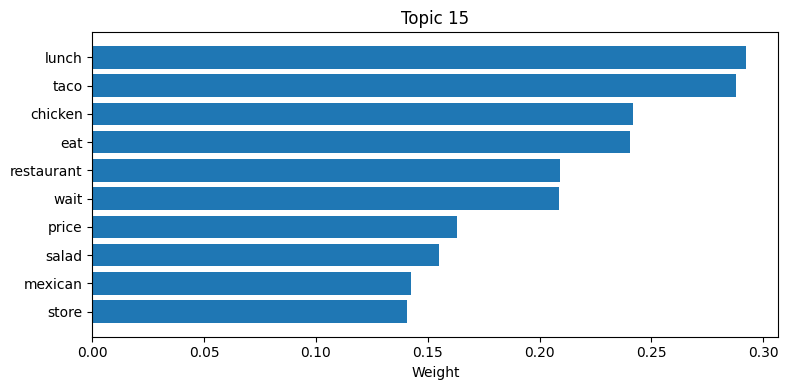

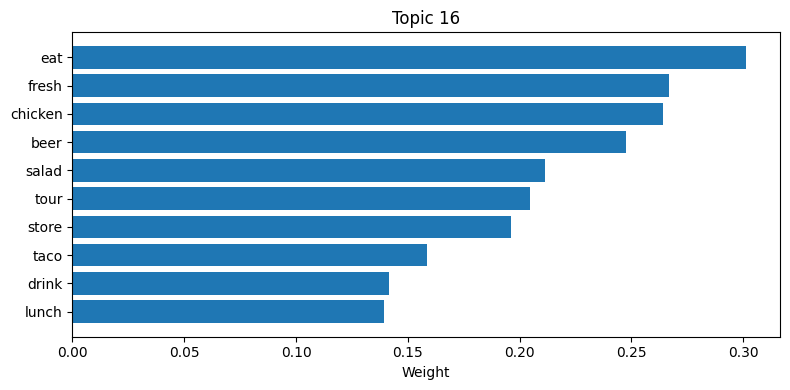

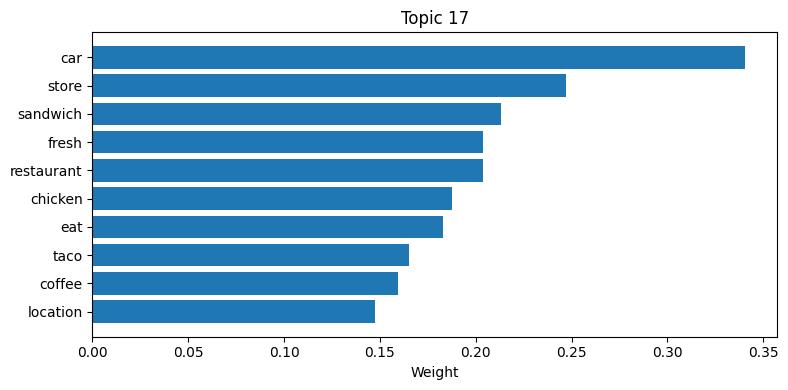

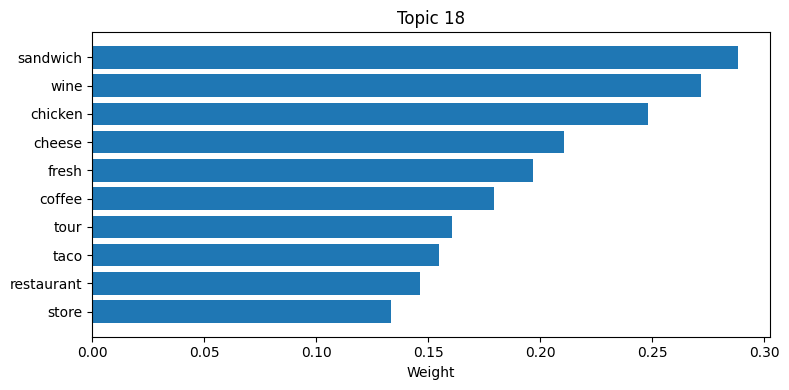

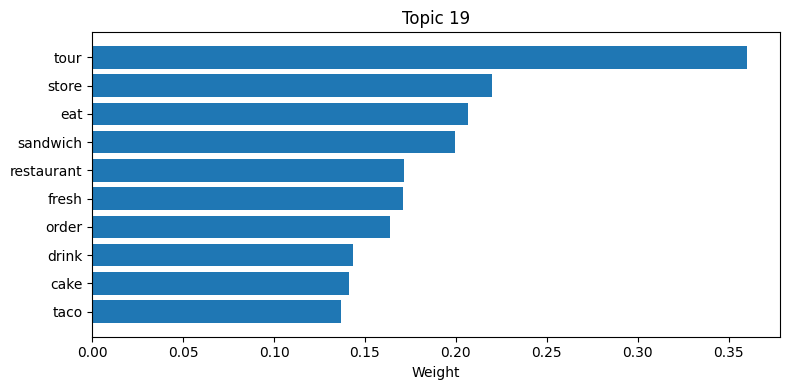

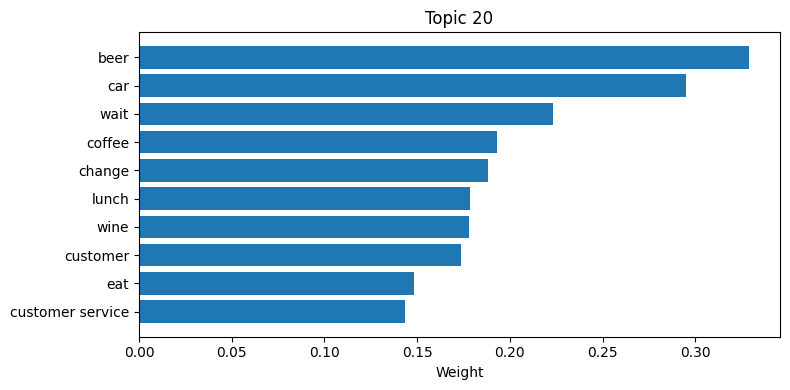

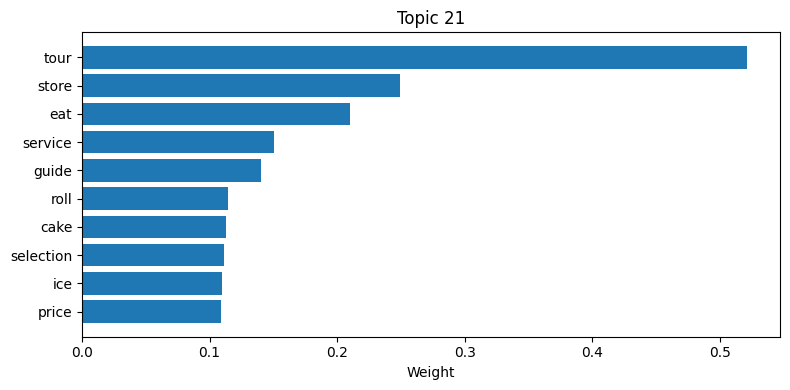

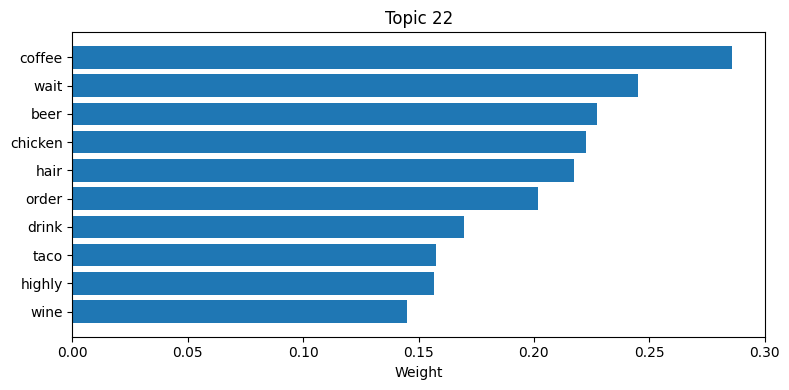

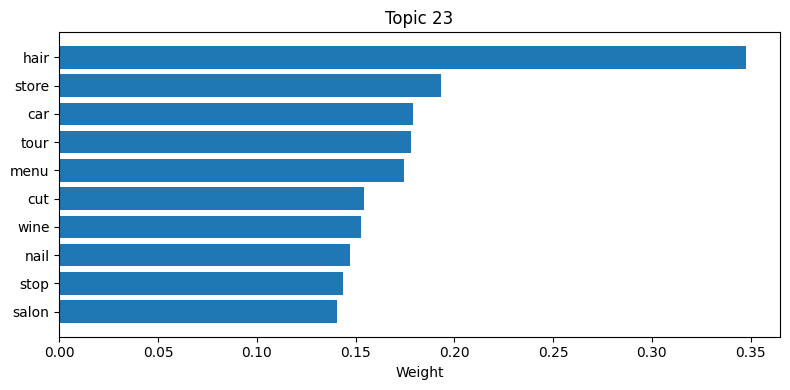

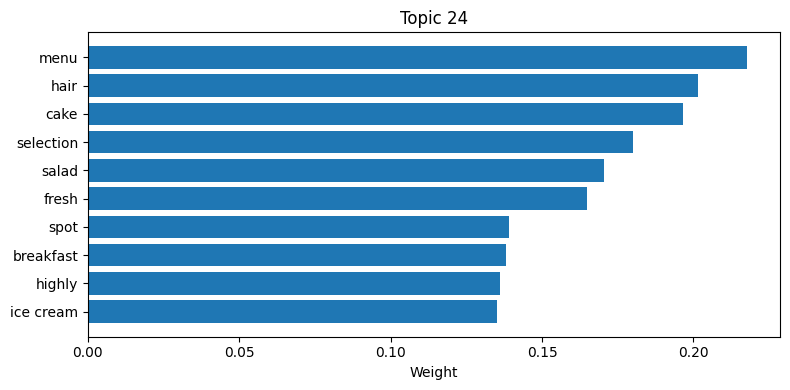

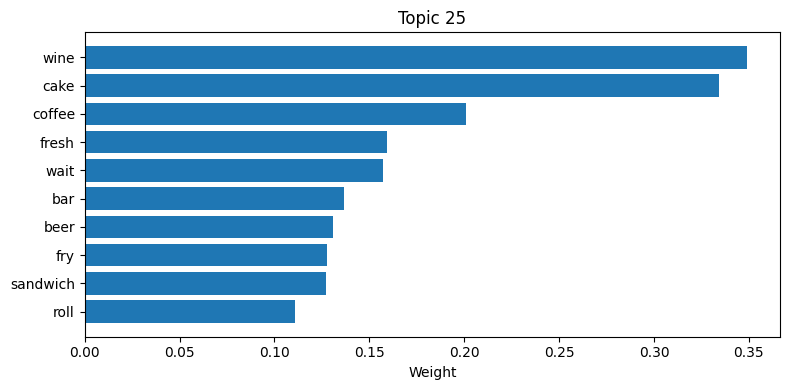

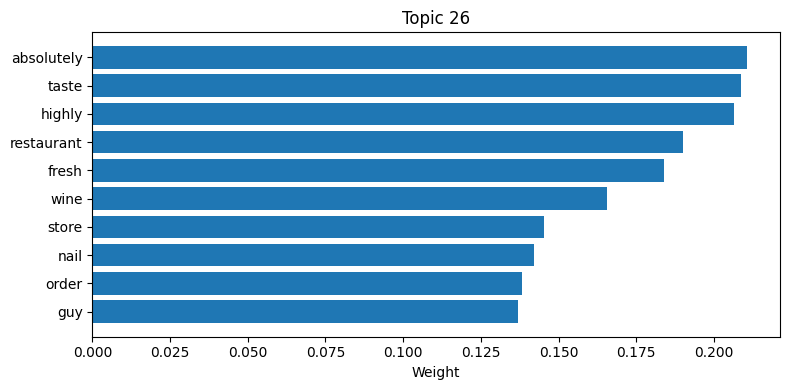

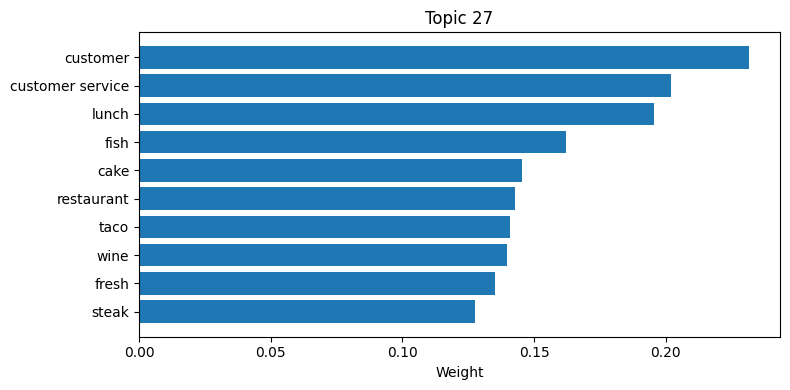

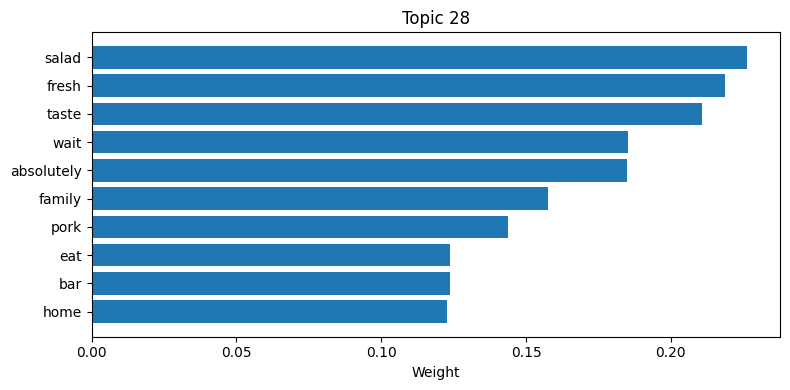

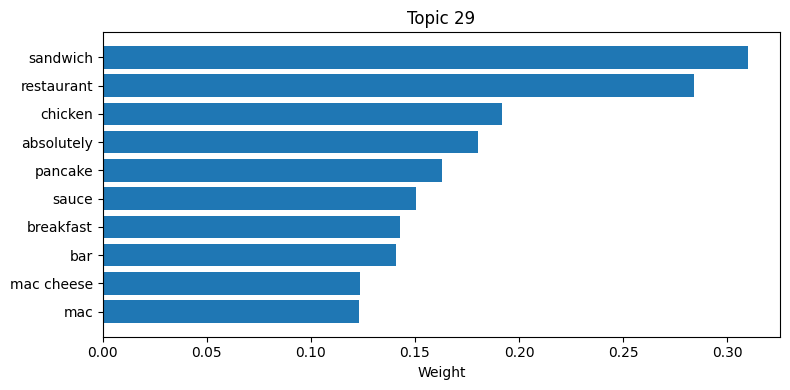

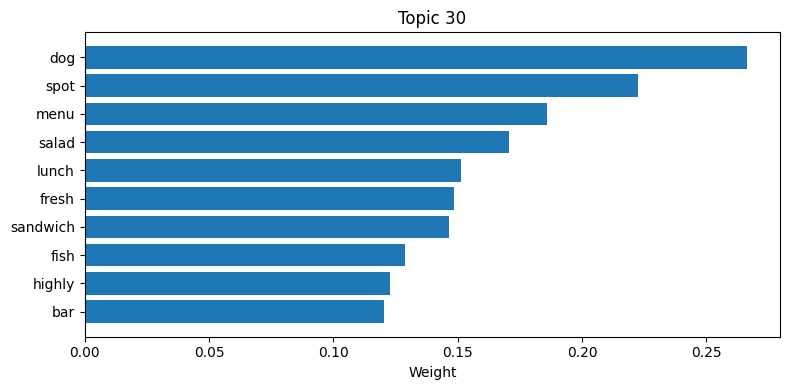

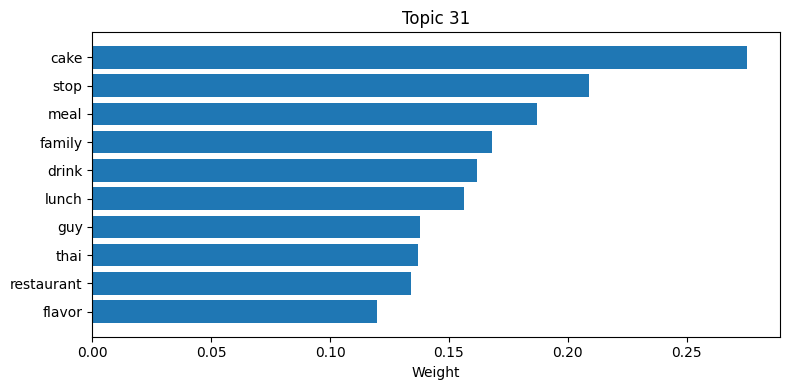

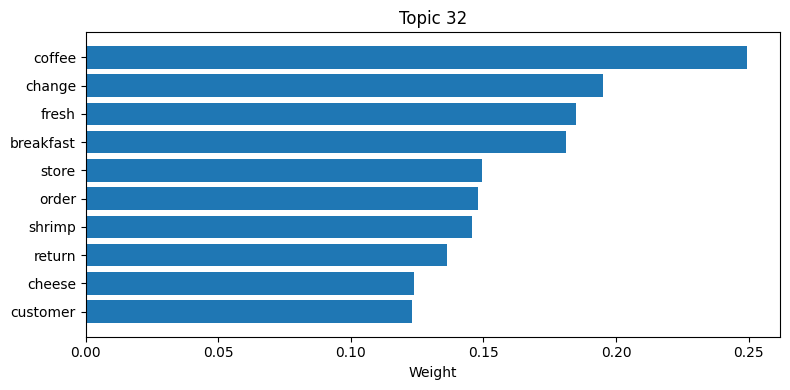

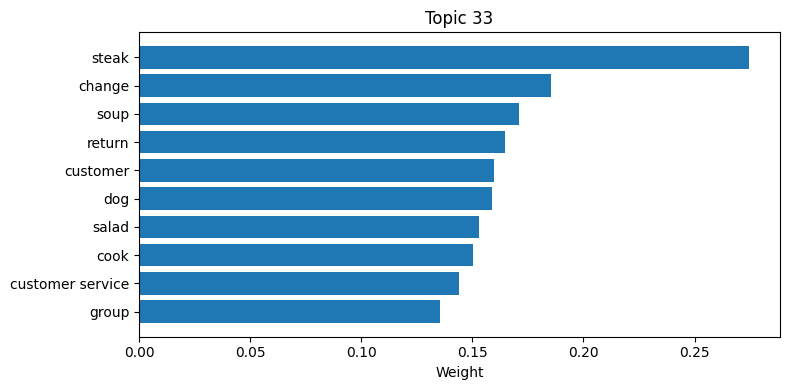

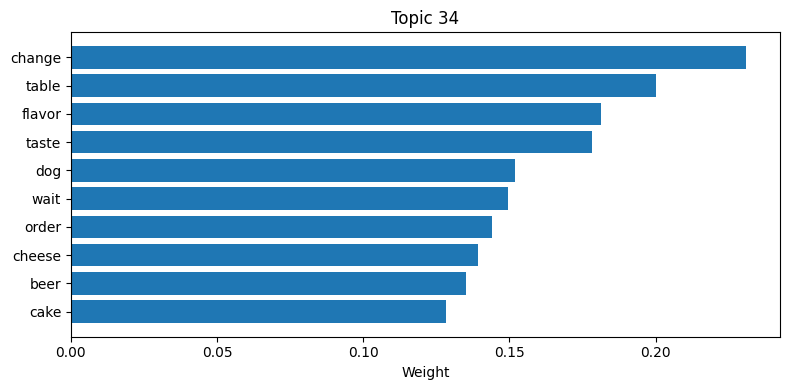

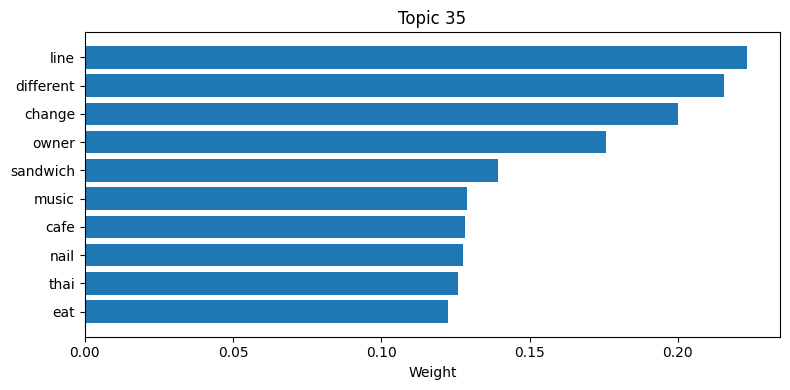

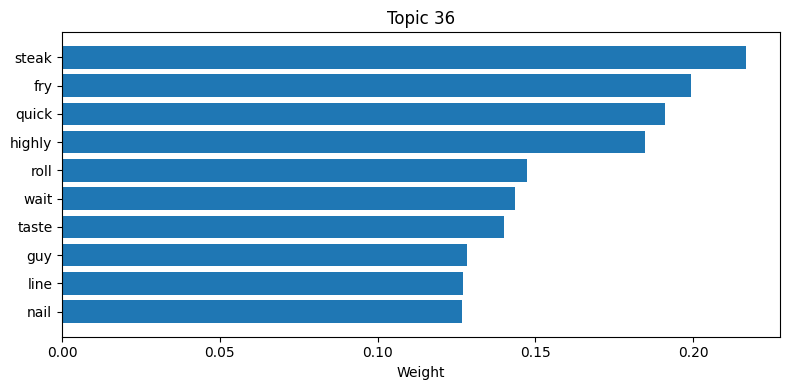

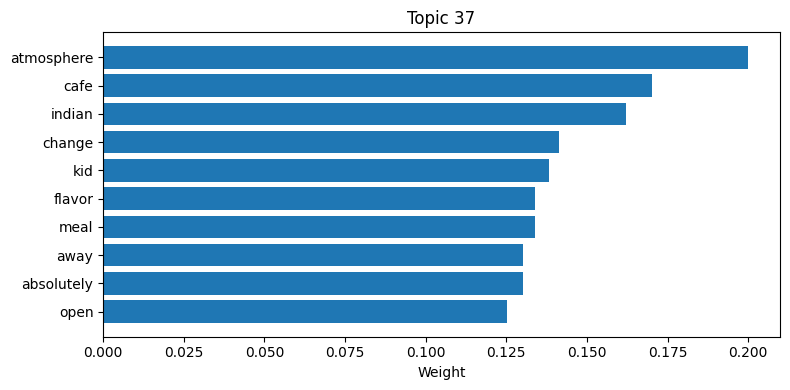

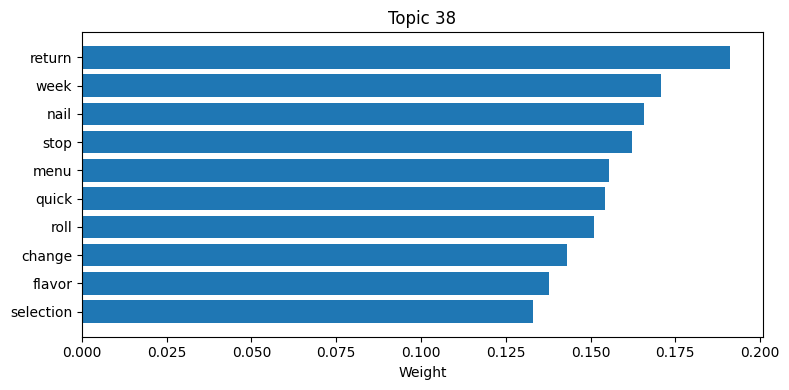

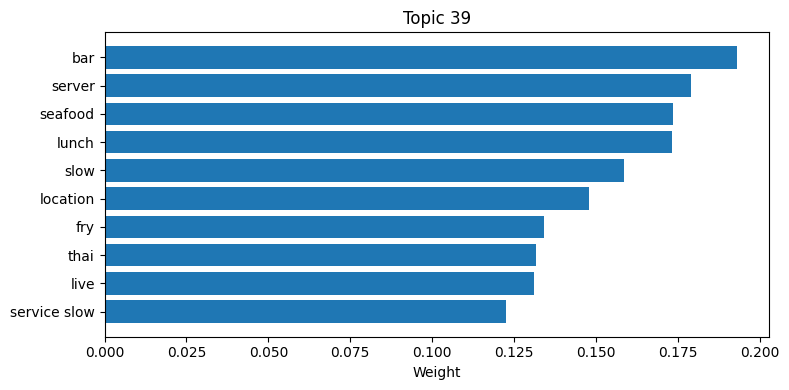

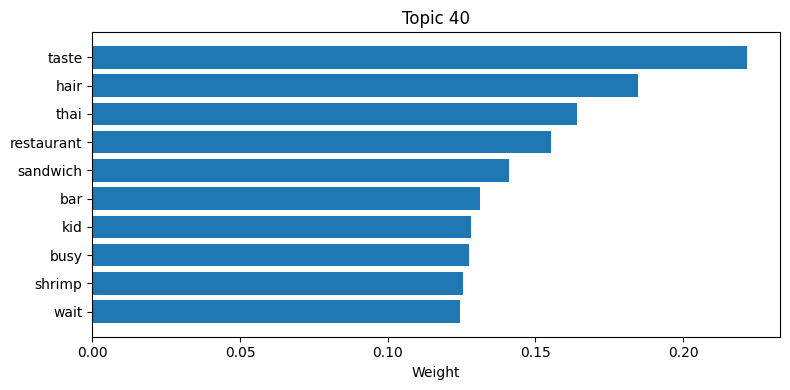

In [40]:
# Zeigt die wichtigsten Wörter je Topic
# Erkenntnis:
# - Sind Topics semantisch klar/interpretiertbar?
# - Gibt es generische oder unscharfe Topics?
# - Sind Topics redundant oder klar getrennt?
plot_multiple_topics(best_row)

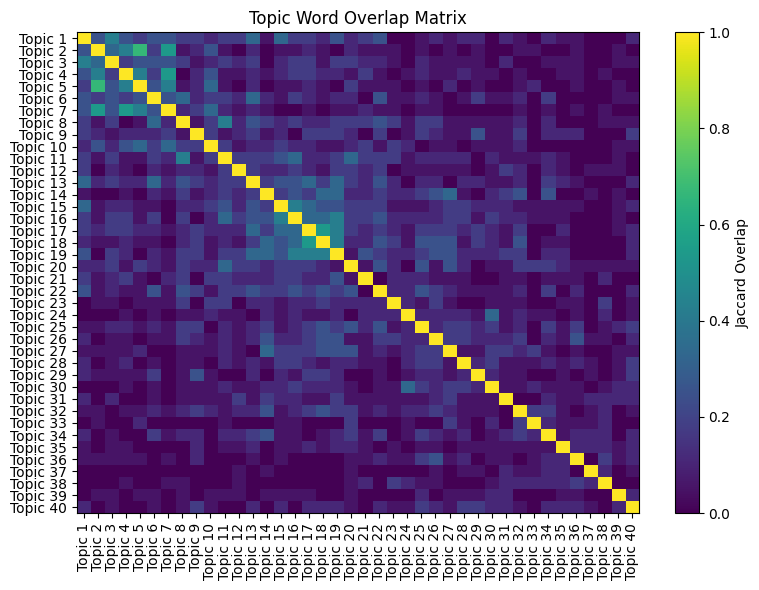

In [81]:
# Zeigt Überschneidungen der Top-Wörter zwischen Topics
# Erkenntnis:
# - Gibt es redundante/ähnliche Topics?
# - Wurden zu viele Topics erzeugt?
# - Wie gut ist die Topic-Separation?
plot_topic_overlap_matrix(best_row)

In [77]:
############
# LSA/TF-IDF - TopWort Vergleich der Top3 Scores (en|de)
############

display_top_topic_models(
    tuning_interpreted_by_lang=lsa_tuning_interpreted_by_lang,
    model_name="LSA/TF-IDF",
    top_k=3
)

display_top_topic_models(
    tuning_interpreted_by_lang=lda_tuning_interpreted_by_lang,
    model_name="LDA/BoW",
    top_k=3
)


=== Top 3 LSA/TF-IDF Modelle (de) ===

--- Rang 1 | Index 0 | Score: 0.5848 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,verbraucherinformation (17.6%),aufgabe erwartungshorizonte (16.4%),schlachthof (10.4%),fördermeng (16.5%),verfolgen (16.0%),münchen (17.5%),schlachtbetrieb (23.6%),arzt (17.6%),münchen (28.4%),persönlich (14.9%)
1,kosten (9.7%),erwartungshorizonte (16.4%),dokumentiert geschlachtet (10.1%),genehmigt (12.0%),verfahrensstand (10.0%),maßnahme (12.3%),genehmigungsbescheide schlachtbetrieb (22.1%),meldung (11.9%),stadt (16.6%),gymnasium (13.0%)
2,umweltinformation (9.4%),fach (16.3%),behördlich überwachung (10.1%),unternehmen (11.4%),bebauungsplanverfahr (9.8%),stadt (10.4%),genehmigungsbescheide (22.1%),unterweisung (10.3%),straße (9.6%),deutsch (11.8%)
3,kosten geringfügig (9.1%),aufgabe (16.1%),geschlachtet tier (10.1%),genehmigt fördermeng (11.0%),baubeginn (9.8%),verbraucherinformation (9.8%),straße (9.9%),unerwünscht (10.1%),akteneinsicht (8.0%),probeunterricht (11.6%)
4,bürgeranfrage behandeln (9.1%),erwartungshorizonte fach (15.2%),geschlachtet (10.1%),kalenderjahr (8.3%),aktueller verfahrensstand (9.4%),fördermeng (8.9%),schlachthof (7.9%),medizinisch (9.7%),stadt münchen (7.2%),gebrauch (9.9%)
5,geringfügig (9.1%),fach deutsch (6.0%),tier (10.1%),trinkwasser (8.3%),gemarkung (9.3%),persönlich (8.7%),hof (3.6%),verdacht (9.3%),anordnung (6.2%),gymnasium persönlich (8.6%)
6,bürgeranfrage (9.1%),deutsch (4.5%),tierart (10.0%),kommunal trinkwasser (8.3%),aktueller (9.2%),bereich (8.5%),augsburg (2.9%),unterwiesen (7.8%),feuerwehr (6.1%),persönlich gebrauch (8.6%)
7,behandeln (9.0%),fach englisch (3.4%),abgeschlossen berichtsjahr (9.8%),entrichten (8.2%),bebauungsplan (9.1%),einsatz (8.1%),genehmigungsbescheid (2.8%),verdacht impfnebenwirkung (7.8%),bewertung (5.9%),schule (7.6%)
8,umweltinformation bund (8.9%),englisch (3.4%),berichtsjahr behördlich (9.7%),wasser (8.1%),recherche abbruch (8.8%),verfolgen (8.0%),metzgerei (2.5%),impfnebenwirkung (7.8%),hiermit (5.9%),feuerwehr (7.4%)
9,bund uig (8.9%),fach physik (2.5%),differenzieren tierart (9.6%),menge (8.0%),verfahrensstand bebauungsplanverfahr (8.8%),schule (7.7%),aschaffenburg (2.5%),verpﬂichten (7.8%),gutachten (5.9%),schwärzen (6.7%)



--- Rang 2 | Index 2 | Score: 0.5800 | Topics: 10 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10
0,verbraucherinformation (17.6%),aufgabe erwartungshorizonte (16.4%),schlachthof (10.4%),fördermeng (16.5%),verfolgen (16.0%),münchen (17.5%),schlachtbetrieb (23.6%),arzt (17.6%),münchen (28.2%),persönlich (15.4%)
1,kosten (9.7%),erwartungshorizonte (16.4%),dokumentiert geschlachtet (10.1%),genehmigt (12.0%),verfahrensstand (10.0%),maßnahme (12.3%),genehmigungsbescheide (22.1%),meldung (11.9%),stadt (16.6%),gymnasium (12.6%)
2,umweltinformation (9.4%),fach (16.3%),behördlich überwachung (10.1%),unternehmen (11.4%),bebauungsplanverfahr (9.8%),stadt (10.4%),genehmigungsbescheide schlachtbetrieb (22.1%),unterweisung (10.3%),straße (9.7%),probeunterricht (11.3%)
3,kosten geringfügig (9.1%),aufgabe (16.1%),geschlachtet tier (10.1%),genehmigt fördermeng (11.0%),baubeginn (9.8%),verbraucherinformation (9.8%),straße (9.9%),unerwünscht (10.1%),akteneinsicht (8.1%),deutsch (11.2%)
4,bürgeranfrage behandeln (9.1%),erwartungshorizonte fach (15.2%),geschlachtet (10.1%),kalenderjahr (8.3%),aktueller verfahrensstand (9.4%),fördermeng (8.9%),schlachthof (7.9%),medizinisch (9.7%),stadt münchen (7.2%),gebrauch (9.6%)
5,geringfügig (9.1%),fach deutsch (6.0%),tier (10.1%),trinkwasser (8.3%),gemarkung (9.3%),persönlich (8.7%),hof (3.6%),verdacht (9.3%),anordnung (6.3%),persönlich gebrauch (8.4%)
6,bürgeranfrage (9.1%),deutsch (4.5%),tierart (10.0%),kommunal trinkwasser (8.3%),aktueller (9.2%),bereich (8.5%),augsburg (2.9%),ärztinn (7.8%),feuerwehr (6.2%),gymnasium persönlich (8.4%)
7,behandeln (9.0%),fach englisch (3.4%),abgeschlossen berichtsjahr (9.8%),entrichten (8.2%),bebauungsplan (9.1%),einsatz (8.1%),genehmigungsbescheid (2.8%),verdacht impfnebenwirkung (7.8%),hiermit (5.9%),feuerwehr (8.3%)
8,datenschutzgesetz umweltinformation (8.9%),englisch (3.4%),berichtsjahr behördlich (9.7%),wasser (8.1%),abbruch benötigen (8.8%),verfolgen (8.0%),metzgerei (2.5%),unterwiesen (7.8%),bewertung (5.9%),schule (7.6%)
9,uig verbesserung (8.9%),fach biologie (2.5%),differenzieren tierart (9.6%),menge (8.0%),dazugehörig bebauungsplan (8.8%),schule (7.7%),aschaffenburg (2.5%),unerwünscht arzneimittelwirkung (7.8%),intern (5.8%),schwärzen (7.3%)



--- Rang 3 | Index 1 | Score: 0.5800 | Topics: 10 ---


...

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,sushi (16.0%),restaurant (17.6%),order (22.6%),pizza (26.7%),order (19.6%),chicken (14.3%),burger (22.8%),wait (15.5%),service (20.0%),nail (18.4%),service (17.4%),hair (26.1%),drink (12.8%),store (21.4%),order (23.7%),order (14.2%),chicken (19.4%),room (18.7%),order (24.4%),table (13.8%)
1,salad (15.6%),family (12.6%),drink (15.3%),sport (10.5%),burger (12.1%),order (12.6%),beer (15.8%),menu (14.2%),car (19.4%),guest (13.9%),coffee (12.8%),tour (16.1%),order (12.5%),restaurant (13.4%),restaurant (12.3%),price (13.4%),flavor (12.1%),hotel (17.2%),price (13.3%),order (13.6%)
2,lunch (11.5%),type (11.5%),service (12.0%),beer (10.3%),wait (10.0%),service (11.4%),bar (9.9%),dinner (10.9%),customer (16.8%),room (13.6%),ice (12.4%),owner (11.2%),flavor (10.7%),price (12.8%),table (10.1%),city (12.1%),service (9.9%),stay (14.4%),service (11.8%),wait (13.0%)
3,roll (9.8%),fresh (9.9%),bar (11.0%),service (9.8%),restaurant (9.3%),server (11.1%),pizza (9.7%),restaurant (10.0%),customer service (9.0%),crab (10.9%),cream (11.5%),cut (10.6%),menu (10.5%),fee (9.0%),wait (9.2%),oyster (9.8%),breakfast (9.2%),service (8.7%),cook (8.2%),thai (12.0%)
4,cheese (9.0%),different (9.6%),taco (8.1%),bar (9.8%),pizza (9.1%),table (9.4%),service (8.3%),bar (8.7%),call (7.2%),wedding (9.0%),ice cream (10.1%),wine (7.7%),fresh (10.1%),ice (8.8%),burger (8.3%),rice (9.7%),meal (8.7%),table (8.2%),fresh (8.0%),room (10.5%)
5,service (8.9%),price (9.0%),restaurant (7.3%),game (9.5%),service (8.7%),return (9.1%),wait (8.1%),start (8.3%),price (6.9%),tour (8.0%),chicken (8.9%),highly (6.7%),line (9.6%),parking (7.5%),dinner (7.8%),eat (8.5%),fish (8.6%),coffee (7.1%),spot (7.9%),noodle (8.7%)
6,chicken (7.6%),pick (7.7%),dish (6.2%),wait (7.0%),chicken (8.2%),sit (8.2%),cheese (6.6%),old (8.2%),wedding (6.3%),price (6.8%),price (8.7%),car (5.9%),cheese (9.4%),menu (7.0%),fry (7.7%),chicken (8.2%),highly (8.5%),breakfast (7.1%),drink (6.9%),service (8.1%)
7,order (7.4%),live (7.6%),beer (6.0%),event (5.8%),star (7.9%),steak (8.2%),beer selection (6.3%),home (8.1%),sale (5.7%),brewery (6.5%),flavor (6.4%),give (5.4%),taste (8.9%),chicken (6.7%),drink (7.1%),shrimp (8.2%),cooky (8.1%),restaurant (6.4%),hot (6.5%),pad (7.1%)
8,fresh (7.3%),seafood (7.6%),stop (6.0%),offer (5.6%),table (7.9%),fry (8.1%),eat (6.3%),server (8.0%),oil (4.4%),technician (6.5%),bean (6.3%),salon (5.2%),sauce (8.2%),item (6.7%),service (7.1%),soup (8.0%),fresh (8.0%),roast (6.2%),make (6.5%),seat (6.6%)
9,eat (6.9%),song (6.9%),salsa (5.5%),order (5.1%),cake (7.2%),taste (7.6%),fry (6.3%),eat (7.9%),pay (4.3%),cheese (6.3%),selection (5.6%),job (5.1%),taco (7.4%),eat (6.6%),wine (6.7%),bar (7.8%),fry (7.5%),sandwich (6.1%),business (6.5%),hotel (6.4%)



--- Rang 2 | Index 30 | Score: 0.7171 | Topics: 20 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,salad (17.6%),restaurant (17.1%),order (21.6%),pizza (28.5%),order (19.3%),chicken (15.4%),burger (23.1%),wait (16.8%),service (23.1%),nail (17.9%),service (17.8%),hair (26.6%),drink (12.9%),store (19.5%),order (23.4%),order (14.6%),chicken (19.2%),hotel (17.6%),order (24.8%),table (14.6%)
1,sushi (12.8%),family (12.5%),drink (15.7%),service (11.8%),burger (11.9%),order (12.2%),beer (14.0%),menu (14.4%),customer (16.0%),room (14.1%),coffee (13.2%),tour (15.5%),order (12.5%),restaurant (12.9%),restaurant (12.2%),price (13.0%),flavor (12.2%),room (16.8%),price (12.7%),order (14.2%)
2,lunch (12.1%),type (10.2%),bar (11.8%),bar (10.5%),wait (10.0%),service (11.4%),pizza (9.6%),dinner (9.5%),car (14.4%),guest (13.7%),ice (12.5%),owner (11.0%),flavor (10.7%),price (12.4%),dinner (9.1%),city (12.2%),service (9.9%),stay (12.2%),service (12.2%),wait (13.1%)
3,cheese (10.0%),fresh (10.1%),service (11.5%),sport (9.8%),pizza (9.6%),server (10.7%),bar (9.5%),restaurant (9.1%),customer service (9.3%),crab (10.6%),cream (11.3%),cut (9.3%),menu (10.5%),chicken (8.6%),wait (8.9%),oyster (10.0%),breakfast (9.1%),service (9.8%),fresh (8.4%),room (10.4%)
4,service (9.3%),different (9.7%),restaurant (7.5%),wait (7.3%),service (9.1%),table (9.3%),service (8.4%),bar (8.9%),wedding (8.1%),wedding (8.8%),ice cream (10.2%),wine (7.6%),line (9.7%),fee (8.4%),service (8.5%),rice (9.7%),meal (9.0%),table (9.1%),cook (8.2%),thai (9.9%)
5,eat (8.3%),price (9.6%),taco (6.9%),game (7.2%),restaurant (8.9%),return (8.7%),wait (7.9%),start (8.7%),price (7.5%),tour (7.8%),price (9.0%),highly (6.9%),fresh (9.6%),service (8.2%),burger (8.1%),shrimp (8.9%),fish (8.7%),coffee (7.5%),spot (7.6%),noodle (8.8%)
6,chicken (7.7%),pick (9.1%),beer (6.7%),beer (6.8%),chicken (8.2%),fry (8.2%),wine (7.1%),server (8.7%),call (5.8%),order (7.4%),chicken (8.0%),car (6.7%),cheese (9.4%),ice (8.2%),table (8.0%),soup (8.1%),highly (8.5%),breakfast (7.0%),business (6.8%),service (8.3%)
7,order (7.6%),live (7.4%),dish (6.4%),offer (6.3%),star (7.9%),taste (8.2%),cheese (7.0%),cheese (8.3%),oil (5.6%),price (6.9%),selection (6.2%),give (5.7%),taste (8.9%),parking (7.6%),drink (7.5%),bar (7.9%),fresh (8.1%),restaurant (6.9%),drink (6.6%),deal (7.5%)
8,fresh (7.4%),song (7.2%),stop (6.1%),event (6.0%),table (7.6%),sit (7.9%),fry (6.8%),eat (8.0%),sale (5.2%),brewery (6.4%),flavor (6.0%),service (5.3%),sauce (8.2%),menu (7.4%),fry (7.2%),eat (7.8%),cooky (7.9%),bar (6.6%),make (6.3%),seat (6.8%)
9,potato (7.2%),order (7.2%),salsa (5.9%),store (5.7%),cake (7.4%),steak (7.8%),eat (6.6%),coffee (7.6%),sushi (5.0%),technician (6.4%),slow (5.7%),job (5.3%),taco (7.5%),eat (6.8%),birthday (7.2%),chicken (7.7%),bit (7.3%),roast (6.5%),hot (6.3%),hotel (6.3%)



--- Rang 3 | Index 27 | Score: 0.6798 | Topics: 20 ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
0,tour (16.9%),service (23.8%),ice (13.8%),order (18.1%),pizza (18.4%),restaurant (13.8%),nail (18.4%),price (16.5%),menu (11.6%),pizza (26.7%),room (28.8%),cake (17.7%),beer (17.6%),hair (24.4%),drink (13.8%),wine (17.0%),sushi (20.2%),chicken (17.0%),wait (21.5%),chicken (19.9%)
1,order (16.2%),car (18.7%),price (11.9%),burger (16.9%),order (17.4%),fresh (13.5%),table (11.1%),service (12.8%),taste (11.0%),order (13.3%),hotel (21.3%),wait (12.9%),lunch (12.0%),order (15.1%),burger (11.8%),sport (15.0%),drink (13.0%),stop (11.9%),service (15.0%),salad (16.6%)
2,roll (9.4%),customer (15.3%),service (11.8%),eat (13.4%),wait (11.9%),service (13.1%),service (10.5%),reasonable (11.7%),server (10.7%),cheese (10.5%),stay (14.6%),tour (12.1%),close (10.8%),menu (9.7%),cheese (11.5%),cut (13.2%),restaurant (11.1%),order (10.9%),line (11.0%),lunch (14.4%)
3,quick (9.3%),call (9.8%),ice cream (10.4%),fry (9.4%),service (9.6%),tasty (10.3%),sit (10.2%),order (11.4%),roast (10.7%),table (7.9%),breakfast (5.5%),line (11.1%),pizza (10.8%),table (8.8%),order (10.4%),bar (10.1%),bar (10.9%),service (10.4%),restaurant (10.2%),order (9.8%)
4,wait (8.7%),customer service (9.0%),cream (9.8%),service (8.1%),offer (7.7%),owner (9.2%),bar (9.1%),salad (9.9%),service (9.8%),burger (7.3%),service (5.4%),seat (9.1%),return (10.7%),restaurant (8.5%),bar (10.1%),class (8.5%),roll (10.8%),lunch (9.4%),meal (9.3%),fresh (9.2%)
5,line (8.7%),let (5.1%),eat (9.8%),sauce (7.5%),table (7.6%),breakfast (9.1%),drink (8.7%),taco (9.7%),table (9.6%),potato (7.2%),check (5.3%),week (8.7%),breakfast (8.3%),flavor (7.4%),wait (9.9%),car (8.0%),service (9.0%),home (9.1%),group (6.9%),restaurant (6.4%)
6,location (8.7%),woman (4.9%),flavor (8.9%),sandwich (7.0%),water (7.0%),grill (8.2%),bartender (8.7%),chicken (7.3%),fresh (9.5%),mac cheese (6.8%),desk (5.1%),coupon (7.8%),craft (8.1%),meal (6.8%),fry (9.7%),sport bar (8.0%),price (7.5%),drink (8.4%),old (6.8%),fried (6.1%)
7,sushi (7.7%),phone (4.6%),order (8.4%),wait (6.8%),dog (7.0%),store (7.9%),order (7.9%),bar (7.3%),thai (9.4%),mac (6.8%),door (4.8%),wall (7.4%),burger (7.6%),fish (6.6%),wine (9.3%),club (6.9%),eat (6.8%),rice (7.9%),watch (6.8%),green (6.0%)
8,drive (7.3%),bring (4.6%),beer (8.1%),crab (6.8%),cold (7.0%),order (7.5%),wait (7.8%),kid (6.8%),sandwich (9.3%),bbq (6.7%),guest (4.8%),tire (6.6%),end (7.4%),cook (6.4%),coffee (7.0%),guy (6.8%),table (5.7%),big (7.5%),menu (6.3%),family (5.9%)
9,eat (7.1%),return (4.3%),sauce (7.1%),chicken (6.0%),taste (6.6%),mexican (7.3%),menu (7.7%),eat (6.4%),pork (8.7%),chocolate (6.7%),restaurant (4.5%),dining (6.6%),nail (6.8%),drink (6.3%),sandwich (6.4%),owner (6.5%),order (5.0%),pick (7.5%),tour (6.1%),birthday (5.8%)


In [123]:
############
# FINAL TOPIC + SENTIMENT PIPELINE
# Separate Vector Spaces:
# - Topic Modeling
# - Sentiment Analysis
############


############
# 2. Manually Select Final Models
############
# IDs = manually evaluated best models

selected_models = {

    "de": {
        "method": "lda",
        "title": "LDA BoW (de)",

        "row": lda_tuning_interpreted_by_lang["de"].iloc[0],

        "vector_topic": vectors_topic["bow_by_lang"]["de"],
        "vector_sentiment": vectors_sentiment["bow_by_lang"]["de"],
    },

    "en": {
        "method": "lsa",
        "title": "LSA TFIDF (en)",

        "row": lsa_tuning_interpreted_by_lang["en"].iloc[3],

        "vector_topic": vectors_topic["tfidf_by_lang"]["en"],
        "vector_sentiment": vectors_sentiment["tfidf_by_lang"]["en"],
    }
}


############
# 3. Extract Final Topic Models
############

def get_selected_topic_model(selection):

    row = selection["row"]
    data = selection["vector_topic"]

    return {
        "model": row["model"],
        "topic_terms": row["topic_terms"],
        "doc_topic_matrix": row["doc_topic_matrix"],
        "documents": data["documents"],
        "features": data["feature_names"],
    }


fitted_models = {}

for lang, selection in selected_models.items():

    fitted_models[lang] = get_selected_topic_model(selection)


############
# 4. Determine Dominant Topic per Document
############

doc_topics = {}

for lang, selection in selected_models.items():

    result = get_selected_topic_model(selection)

    doc_topic_matrix = result["doc_topic_matrix"]
    documents = result["documents"]

    method = selection["method"]

    if method == "lda":
        dominant_topics = doc_topic_matrix.argmax(axis=1)
        topic_strengths = doc_topic_matrix.max(axis=1)

    elif method == "lsa":
        abs_matrix = np.abs(doc_topic_matrix)
        dominant_topics = abs_matrix.argmax(axis=1)
        topic_strengths = abs_matrix.max(axis=1)

    else:
        raise ValueError(f"Unknown method: {method}")

    doc_topics[lang] = pd.DataFrame({
        "doc_id": range(len(documents)),
        "document": documents,
        "dominant_topic": dominant_topics + 1,
        "topic_strength": topic_strengths
    })

print(doc_topics.keys())

############
# 5. Sentiment Analysis
############

sentiments = {}

for lang, selection in selected_models.items():

    sentiments[lang] = build_sentiment_df(
        selection["vector_sentiment"],
        lang=lang
    )

    
############
# 6. Merge Topic + Sentiment
############

doc_topics_sentiment = {}

for lang in doc_topics.keys():

    doc_topics_sentiment[lang] = doc_topics[lang].merge(
        sentiments[lang],
        on="doc_id",
        how="left",
        suffixes=("_topic", "_sentiment")
    )

############
# 7. Aggregate Topic + Sentiment Matrix
############

topic_sentiment_summary = {}

for lang, df in doc_topics_sentiment.items():

    topic_sentiment_summary[lang] = (
        df.groupby("dominant_topic")
        .agg(
            documents=("document_topic", "count"),
            avg_topic_strength=("topic_strength", "mean"),
            avg_sentiment=("sentiment_score", "mean"),
            positive=("sentiment_label", lambda x: (x == "positive").sum()),
            neutral=("sentiment_label", lambda x: (x == "neutral").sum()),
            negative=("sentiment_label", lambda x: (x == "negative").sum())
        )
        .reset_index()
    )


############
# 8. Display Final Topic + Sentiment Matrices
############

for lang, summary_df in topic_sentiment_summary.items():

    selection = selected_models[lang]

    print(f"\n=== Topic + Sentiment Vergleich ({lang}) ===")

    display(
        style_topic_sentiment(
            summary_df,
            f"{selection['title']} - Topic & Sentiment Matrix",
            pos_threshold=0.1,
            neg_threshold=-0.1
        )
    )

dict_keys(['de', 'en'])

=== Topic + Sentiment Vergleich (de) ===


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,11,0.872066,0.298136,1,10,0
2,38,0.820834,-0.010474,0,36,2
3,33,0.852596,-0.000094,2,30,1
4,33,0.939655,0.041958,3,29,1
5,30,0.923980,0.085187,4,26,0
6,54,0.855426,0.009350,2,50,2
7,42,0.782261,0.044821,1,41,0
8,52,0.819802,0.069658,3,48,1
9,65,0.865900,-0.034674,1,62,2
10,31,0.907462,-0.026887,2,27,2



=== Topic + Sentiment Vergleich (en) ===


dominant_topic,documents,avg_topic_strength,avg_sentiment,positive,neutral,negative
1,382,0.166588,0.656181,293,66,23
2,37,0.203607,0.689938,31,4,2
3,37,0.364395,0.704235,31,3,3
4,35,0.224268,0.765603,30,3,2
5,32,0.224573,0.758997,29,2,1
6,19,0.214682,0.723147,16,2,1
7,15,0.324469,0.489507,11,2,2
8,27,0.198022,0.604526,20,5,2
9,35,0.199732,0.865414,33,1,1
10,42,0.141082,0.700476,36,3,3


In [117]:
#display_selected_model_topic_terms(
#    selected_models,
#    weight_col="weight_pct"
#)

def show_reviews_for_topic(
    doc_topics_sentiment,
    lang,
    topic_id,
    sentiment_label=None,
    n=10,
    sort_by="topic_strength"
):
    df = doc_topics_sentiment[lang].copy()

    df = df[df["dominant_topic"] == topic_id]

    if sentiment_label is not None:
        df = df[df["sentiment_label"] == sentiment_label]

    df = df.sort_values(sort_by, ascending=False)

    cols = [
        "doc_id",
        "dominant_topic",
        "topic_strength",
        "sentiment_score",
        "sentiment_label"
    ]

    # Falls du suffixes beim Merge hast
    if "document_topic" in df.columns:
        cols.append("document_topic")
    elif "document" in df.columns:
        cols.append("document")

    return df[cols].head(n)
#doc_topics_sentiment["en"].head()
#doc_topics_sentiment["de"].head()
pd.set_option("display.max_colwidth", 1000)
show_reviews_for_topic(
    doc_topics_sentiment,
    lang="en",
    topic_id=1,
    sentiment_label="negative",
    n=10
)

,doc_id,dominant_topic,topic_strength,sentiment_score,sentiment_label,document_topic
469,469,1,0.279057,-0.8268,negative,short byob newtown square hit mark big portion decent price hungry fellini cafe bryn mawr memorable moment speed bump reach potential late past friday reservation wife arrive vacant table available seat break table instead put seater odd away kid bit privacy instead sit connect table manager move seater fine later member wait indication intention whisk bottle wine silverware run table eye contact simple follow hint shrug roll interior quaint lighting dim meal loud loud kid despite close quarter neighbor kid actually certain waitress extremely polite offer energy lack dinner order caesar salad share main course wife opt usual tagliatelli mushroom cream sauce tortellini pasticiatti meal piece bruschetta loaf crusty italian bread butter packet strange italian restaurant overall somewhat minor hiccup caesar salad warm plate salad legendary chilled warm plate frozen pea tortellini dish fine pea thaw pea thaw mar craft dish pay manager allow use expired card gesture require push induce f...
549,549,1,0.274150,-0.7717,negative,awefull zero star write absolute dining sake house esp family stay decide month old son sushi date arrive sake house table close sit immediately simple ice water lemon waiter later water order simple roll son start cold sake wait order settle min later water waiter hot sake instead cold later roll son finally cold sake request water cup son lemon table order order water perturb waiter check order finally nearly wait deal antsy son wait see chef order decide finally wait check drink reluctantly pay hospitality industry expect forgive english second language tough able wait table issue waiting deal fussy hungry toddler single mother offer drink understand accommodate principal waiste baby money waiste rare plan busy mother listen service money stay away
774,774,1,0.260650,-0.8750,negative,arado monday group shocked arrival sanitize large table quickly table smell sanitized rag buzz mean smell waiter appear drink order beer margarita margarita drinker group declare price drink mexican beer order bring fresh hot snarf tasty meet attentively quiet waiter let specific request bean light cheese meet kitchen belly red garter mind numb strip club wrap arado wrap decent shabby drink price cheap start affordable filling eat fountain square strip club
550,550,1,0.254998,-0.7506,negative,stage cool raise light sound system fog machine big dance floor service greet podium table figure sit wait employee menu see lady stop remember give certain kitchen close table kitchen closed kinda maybe stop order ahead exact lady seat table menu order bring freakin french fry sit watch eat french fry instead
700,700,1,0.251046,-0.8360,negative,seafood restaurant edge pear expectation set high wife order different plate menu order cioppino clam chowder crab salad sandwich clam chowder flavor consistency order cioppino lack flavor variety sea lack order pass crab salad sandwich lack flavor mayo overpower crab flavor non existent onion ring greasy order overall okay seat outside pear overlook ocean inside service prepared wait bit seat selective order menu tend hit miss
98,98,1,0.243113,-0.9337,negative,service management order waiter start manager offer drink cold eat half wait dine cracker barrel
41,41,1,0.235810,-0.9337,negative,straight point cheap taste cheap price location dessert edible item bake chicken fry chicken mashed potato salad bar meat cheese bar ravioli pizza waitress meh counter meat slicing station shrimp devein mexican station breakfast egg actually egg benedict cut ham english muffin occasion steak shrimp bread item decor nightmare imagine
313,313,1,0.226025,-0.9502,negative,han dynasty spot old mid atlantic restaurant unchanging menu han dynasty olde city maybe biased service check conversation hear peanut allergy peanut dish order han sister han dynasty month number note different branch different sp

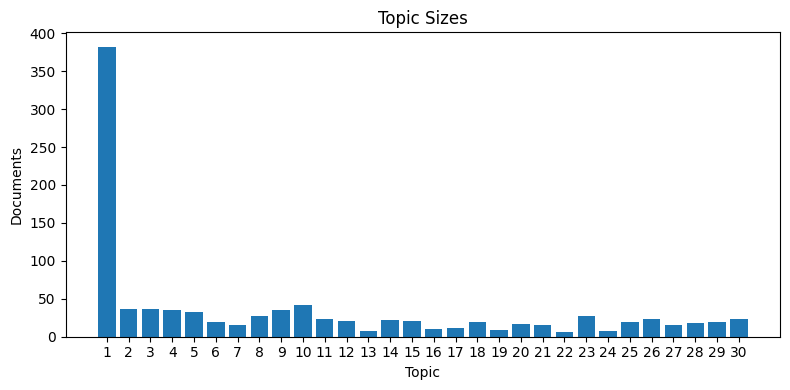

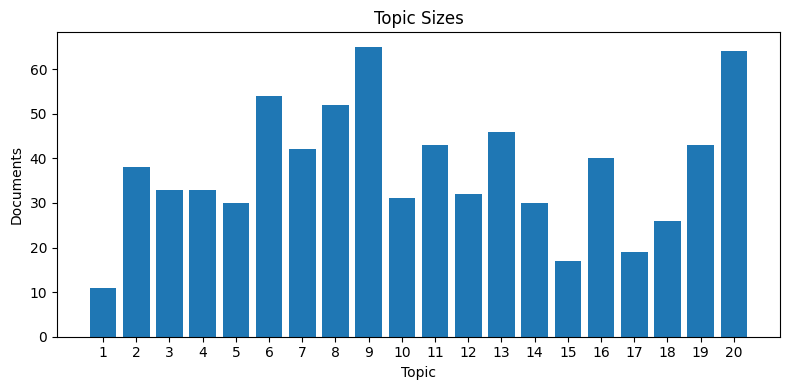

In [110]:
# Zeigt die Anzahl Dokumente pro dominantem Topic
# Erkenntnis:
# - Sind Topics ausgewogen verteilt?
# - Dominiert ein einzelnes Topic zu stark?
# - Gibt es irrelevante Mini-Topics?
plot_topic_sizes(doc_topics["en"])
plot_topic_sizes(doc_topics["de"])

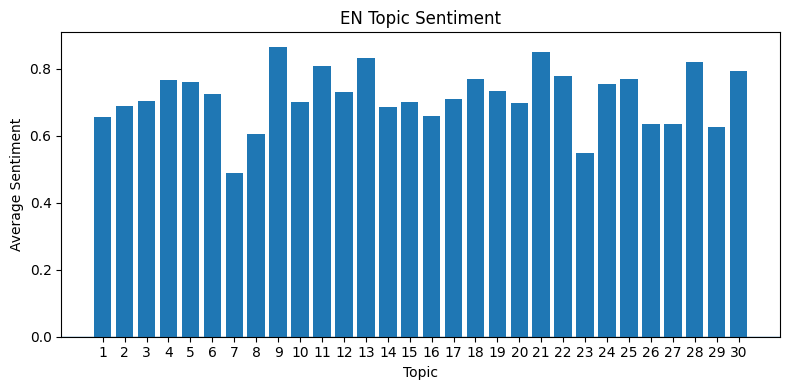

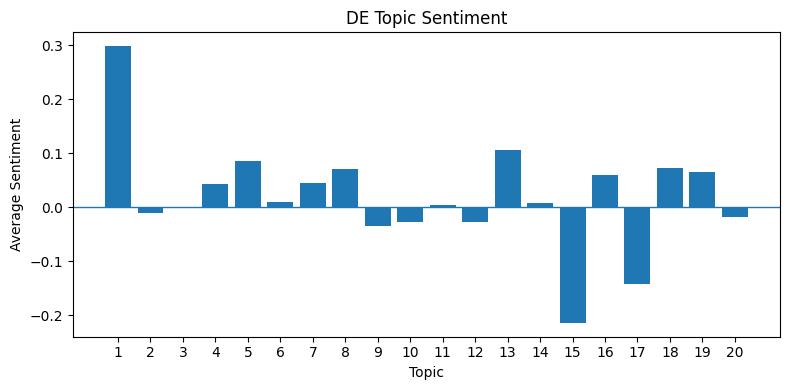

In [118]:
# Zeigt durchschnittliches Sentiment pro Topic
# Erkenntnis:
# - Welche Themen sind positiv/negativ?
# - Gibt es emotional stark geladene Topics?
# - Wie unterscheiden sich Topics semantisch/emotional?
plot_topic_sentiment(
    topic_sentiment_summary["en"],
    title="EN Topic Sentiment"
)

plot_topic_sentiment(
    topic_sentiment_summary["de"],
    title="DE Topic Sentiment"
)

In [105]:

def display_selected_model_topic_terms(selected_models, weight_col="weight_pct"):
    """
    Gibt die Top-Wörter pro Topic für manuell ausgewählte Modelle aus.
    Funktioniert mit Struktur:
    selected_models["de"]["row"]
    selected_models["en"]["row"]
    """

    for lang, selection in selected_models.items():

        row = selection["row"]
        title = selection["title"]

        score = row.get("overall_score", None)
        n_topics = row.get("n_topics", len(row["topic_terms"]))

        print(f"\n=== Ausgewähltes Topic-Modell ({lang}) ===")

        if score is not None:
            print(
                f"\n--- {title} | "
                f"Score: {score:.4f} | "
                f"Topics: {n_topics} ---"
            )
        else:
            print(
                f"\n--- {title} | "
                f"Topics: {n_topics} ---"
            )

        display(topic_terms_to_table(row, weight_col=weight_col))


def build_sentiment_df(vector_data, lang="en"):
    """
    Erstellt Sentiment-Scores je Dokument.
    Enthält doc_id für sauberen Merge mit Topic-Zuordnung.
    """

    analyzer = SentimentIntensityAnalyzer()

    documents = vector_data["documents"]
    records = []

    for doc_id, doc in enumerate(documents):
        scores = analyzer.polarity_scores(str(doc))
        compound = scores["compound"]

        pos_threshold = 0.5
        neg_threshold = -0.5

        if compound >= pos_threshold:
            label = "positive"
        elif compound <= neg_threshold:
            label = "negative"
        else:
            label = "neutral"

        records.append({
            "doc_id": doc_id,
            "document": doc,
            "sentiment_score": compound,
            "sentiment_label": label,
            "sentiment_pos": scores["pos"],
            "sentiment_neu": scores["neu"],
            "sentiment_neg": scores["neg"]
        })

    return pd.DataFrame(records)

In [98]:
def plot_topic_sentiment_from_summary(summary, method_key, lang):
    df = summary[method_key][lang]

    plot_df = df.set_index("dominant_topic")[[
        "positive", "neutral", "negative"
    ]]

    plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f'{methods[method_key]["title"]} ({lang}) - Topic + Sentiment')
    plt.xlabel("Topic")
    plt.ylabel("Anzahl Dokumente")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_topic_sentiment_from_summary(topic_sentiment_summary, "bow_lda", "de")

KeyError: 'bow_lda'

In [48]:
def topic_terms_to_table(row, weight_col="weight_pct"):
    return pd.DataFrame({
        topic: [
            f'{item["word"]} ({item[weight_col]:.1f}%)'
            for item in terms
        ]
        for topic, terms in row["topic_terms"].items()
    })

    return pd.DataFrame(records)
def display_top_topic_models(tuning_interpreted_by_lang, model_name, top_k=3, weight_col="weight_pct"):
    for lang, tuning_df in tuning_interpreted_by_lang.items():

        print(f"\n=== Top {top_k} {model_name} Modelle ({lang}) ===")

        for rank, (idx, row) in enumerate(tuning_df.head(top_k).iterrows(), start=1):
            print(
                f"\n--- Rang {rank} | Index {idx} | "
                f"Score: {row['overall_score']:.4f} | "
                f"Topics: {row['n_topics']} ---"
            )

            display(topic_terms_to_table(row, weight_col=weight_col))


def plot_topic_words(row, topic_id=1, top_n=10, title=None):
    topic_key = f"Topic {topic_id}"
    terms = row["topic_terms"][topic_key][:top_n]

    words = [t["word"] for t in terms][::-1]
    weights = [t["abs_weight"] for t in terms][::-1]

    plt.figure(figsize=(8, 4))
    plt.barh(words, weights)
    plt.xlabel("Weight")
    plt.title(title or f"{topic_key} - Top Words")
    plt.tight_layout()
    plt.show()
    
def plot_multiple_topics(row, topic_ids=None, top_n=10):
    topic_terms = row["topic_terms"]

    if topic_ids is None:
        topic_ids = range(1, len(topic_terms) + 1)

    for topic_id in topic_ids:
        plot_topic_words(
            row=row,
            topic_id=topic_id,
            top_n=top_n,
            title=f"Topic {topic_id}"
        )

def plot_multiple_topics(row, topic_ids=None, top_n=10):
    topic_terms = row["topic_terms"]

    if topic_ids is None:
        topic_ids = range(1, len(topic_terms) + 1)

    for topic_id in topic_ids:
        plot_topic_words(
            row=row,
            topic_id=topic_id,
            top_n=top_n,
            title=f"Topic {topic_id}"
        )

def plot_topic_term_heatmap(row, top_n=10, title="Topic-Term Heatmap"):
    topic_terms = row["topic_terms"]

    records = []

    for topic, terms in topic_terms.items():
        for term in terms[:top_n]:
            records.append({
                "topic": topic,
                "word": term["word"],
                "weight": term["abs_weight"]
            })

    df = pd.DataFrame(records)

    heatmap_data = (
        df.pivot_table(
            index="word",
            columns="topic",
            values="weight",
            fill_value=0
        )
    )

    plt.figure(figsize=(12, max(5, len(heatmap_data) * 0.25)))
    plt.imshow(heatmap_data, aspect="auto")
    plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=90)
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)
    plt.colorbar(label="Weight")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def compute_topic_overlap_matrix(row):
    topics = {
        topic: [item["word"] for item in terms]
        for topic, terms in row["topic_terms"].items()
    }

    topic_names = list(topics.keys())
    matrix = np.zeros((len(topic_names), len(topic_names)))

    for i, topic_a in enumerate(topic_names):
        for j, topic_b in enumerate(topic_names):
            set_a = set(topics[topic_a])
            set_b = set(topics[topic_b])

            union = set_a | set_b
            intersection = set_a & set_b

            matrix[i, j] = len(intersection) / len(union) if union else 0

    return pd.DataFrame(matrix, index=topic_names, columns=topic_names)

def plot_topic_overlap_matrix(row, title="Topic Word Overlap Matrix"):
    overlap_df = compute_topic_overlap_matrix(row)

    plt.figure(figsize=(8, 6))
    plt.imshow(overlap_df, aspect="auto")
    plt.xticks(range(len(overlap_df.columns)), overlap_df.columns, rotation=90)
    plt.yticks(range(len(overlap_df.index)), overlap_df.index)
    plt.colorbar(label="Jaccard Overlap")
    plt.title(title)
    plt.tight_layout()
    plt.show()
def plot_topic_sizes(doc_topic_df, title="Topic Sizes"):
    counts = (
        doc_topic_df["dominant_topic"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8, 4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.xlabel("Topic")
    plt.ylabel("Documents")
    plt.title(title)
    plt.tight_layout()
    plt.show()
def plot_topic_sentiment(df, title="Topic Sentiment"):

    ax = df.plot(
        x="dominant_topic",
        y="avg_sentiment",
        kind="bar",
        legend=False,
        figsize=(12, 5)
    )

    ax.set_title(title)
    ax.set_xlabel("Topic")
    ax.set_ylabel("Average Sentiment")

    plt.axhline(0, color="black", linewidth=1)

    plt.show()